In [1]:
import os
import requests
import io
import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, accuracy_score, log_loss
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from google.colab import files


In [2]:
# Download processed data from GitHub

REPO_API = "https://api.github.com/repos/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/contents/ProcessedData"
os.makedirs("processed", exist_ok=True)

response = requests.get(REPO_API)
if response.status_code == 200:
    for f in response.json():
        if f["type"] == "file" and f["name"].endswith(".csv"):
            r = requests.get(f["download_url"])
            with open(f"processed/{f['name']}", "wb") as fh:
                fh.write(r.content)
            print(f"Downloaded: {f['name']}")
else:
    print(f"GitHub API error: {response.status_code}")
    print("Falling back — upload files manually.")

Downloaded: Sample_Submission.csv
Downloaded: predictions_merged.csv
Downloaded: processed_tournament_data.csv
Downloaded: processed_tournament_data_clean.csv
Downloaded: processed_tournament_data_complete_file.csv
Downloaded: season_avgs_t1.csv
Downloaded: season_avgs_t2.csv


In [3]:
# Load data
TRAIN_PATH = "processed/processed_tournament_data_complete_file.csv"
PRED_PATH  = "processed/predictions_merged_upload.csv" #Note:
#Due to predictions_merged.csv file size, use upload box instead, download predictions_merged.csv from
#https://github.com/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/tree/main/ProcessedData
#Or generate the file using https://github.com/COMP3608-GROUP-9-PROJECT/COMP3608_PROJECT/blob/main/DataPreProcessing-clean.ipynb


# Fall back: prompt user to upload if files were not in the repo
for path in [TRAIN_PATH, PRED_PATH]:
    if not os.path.exists(path):
        print(f"File '{path}' not found. Please upload it now.")
        uploaded = files.upload()
        # Move to expected location
        for name in uploaded:
            os.makedirs(os.path.dirname(path), exist_ok=True)
            os.rename(name, path)

df_train = pd.read_csv(TRAIN_PATH)
df_pred  = pd.read_csv(PRED_PATH)

print(f"Training rows: {df_train.shape[0]:,}  |  columns: {df_train.shape[1]}")
print(f"Prediction rows: {df_pred.shape[0]:,}  |  columns: {df_pred.shape[1]}")

File 'processed/predictions_merged_upload.csv' not found. Please upload it now.


Saving predictions_merged.csv to predictions_merged.csv
Training rows: 4,552  |  columns: 76
Prediction rows: 131,407  |  columns: 73


In [4]:
# Feature selection

FEATURES = [ # Core signal features: seeds, efficiency, rebounding, turnovers, ratings, grades.
    # Division flag (0 = Women's, 1 = Men's)
    "Divison",

    # Seeding
    "T1Seed", "T2Seed", "SeedDifference",

    # Scoring efficiency FGA without FGM to avoid multicollinearity with makes
    "T1AverageFGA", "T2AverageFGA",
    "T1AverageFGM3", "T2AverageFGM3",

    # Free throws
    "T1AverageFTM", "T1AverageFTA",
    "T2AverageFTM", "T2AverageFTA",

    # Rebounding
    "T1AverageOR", "T1AverageDR",
    "T2AverageOR", "T2AverageDR",

    # Assists, turnovers, steals, blocks, fouls
    "T1AverageAst", "T1AverageTO", "T1AverageStl", "T1AverageBlk", "T1AveragePF",
    "T2AverageAst", "T2AverageTO", "T2AverageStl", "T2AverageBlk", "T2AveragePF",

    # Opponent allowed stats
    "T1AverageOpponentScore",
    "T1AverageOpponentFGA", "T1AverageOpponentFGM3",
    "T1AverageOpponentOR", "T1AverageOpponentTO",
    "T1AverageOpponentBlk", "T1AverageOpponentPF",

    "T2AverageOpponentScore",
    "T2AverageOpponentFGA", "T2AverageOpponentFGM3",
    "T2AverageOpponentOR", "T2AverageOpponentTO",
    "T2AverageOpponentBlk", "T2AverageOpponentPF",

    # Elo strength ratings
    "T1Rating", "T2Rating", "RatingDifference",

    # GLM performance grades
    "T1Grade", "T2Grade", "GradeDifference",
]

FEATURES = [f for f in FEATURES if f in df_train.columns]

print(f"Using {len(FEATURES)} features:")
print(FEATURES)

Using 46 features:
['Divison', 'T1Seed', 'T2Seed', 'SeedDifference', 'T1AverageFGA', 'T2AverageFGA', 'T1AverageFGM3', 'T2AverageFGM3', 'T1AverageFTM', 'T1AverageFTA', 'T2AverageFTM', 'T2AverageFTA', 'T1AverageOR', 'T1AverageDR', 'T2AverageOR', 'T2AverageDR', 'T1AverageAst', 'T1AverageTO', 'T1AverageStl', 'T1AverageBlk', 'T1AveragePF', 'T2AverageAst', 'T2AverageTO', 'T2AverageStl', 'T2AverageBlk', 'T2AveragePF', 'T1AverageOpponentScore', 'T1AverageOpponentFGA', 'T1AverageOpponentFGM3', 'T1AverageOpponentOR', 'T1AverageOpponentTO', 'T1AverageOpponentBlk', 'T1AverageOpponentPF', 'T2AverageOpponentScore', 'T2AverageOpponentFGA', 'T2AverageOpponentFGM3', 'T2AverageOpponentOR', 'T2AverageOpponentTO', 'T2AverageOpponentBlk', 'T2AverageOpponentPF', 'T1Rating', 'T2Rating', 'RatingDifference', 'T1Grade', 'T2Grade', 'GradeDifference']


In [5]:
# Impute missing values
# Seeds default to 17 (worse than any real seed) so NaN seeds hurt the prediction.
# Ratings default to 1000 (starting Elo). Grades default to 0.

fill_vals = {
    "T1Seed": 17, "T2Seed": 17, "SeedDifference": 0,
    "T1Rating": 1000, "T2Rating": 1000, "RatingDifference": 0,
    "T1Grade": 0, "T2Grade": 0, "GradeDifference": 0,
}

for col in FEATURES:
    if col in fill_vals:
        df_train[col] = df_train[col].fillna(fill_vals[col])
        df_pred[col]  = df_pred[col].fillna(fill_vals[col])
    else:
        med = df_train[col].median()
        df_train[col] = df_train[col].fillna(med)
        df_pred[col]  = df_pred[col].fillna(med)

print(f"Missing in training features: {df_train[FEATURES].isnull().sum().sum()}")
print(f"Missing in prediction features: {df_pred[FEATURES].isnull().sum().sum()}")

Missing in training features: 0
Missing in prediction features: 0


In [6]:
# Best hyperparameters from RandomizedSearchCV

best_params = {
    "n_estimators":      300,
    "min_samples_leaf":  8,
    "max_depth":         10,
    "criterion":         "entropy",
    "random_state":      1,
    "n_jobs":           -1
}

In [7]:
df_train = df_train.sort_values("Season").reset_index(drop=True)

# Define target
y = df_train["Win"]

# Create dataframe to hold features
X = df_train[FEATURES]

seasons_all = sorted(df_train["Season"].unique())

# Initialize a list to store scores for each fold
results = []

# Arrays to collect out-of-fold predictions for accurate evaluation
oof_probs = np.zeros(len(y))
oof_preds = np.zeros(len(y))

# Iterate over each season using leave-one-season-out cross-validation
for season in seasons_all:
    mask_train = df_train["Season"] != season
    mask_val = df_train["Season"] == season

    X_train = X[mask_train]
    X_test = X[mask_val]
    y_train = y[mask_train]
    y_test = y[mask_val]

    test_index = df_train.index[mask_val]

    # Create and train the Random Forest model on all seasons except the held-out one
    rf_model = RandomForestClassifier(**best_params)
    rf_model.fit(X_train, y_train)

    # Predict probabilities for the held-out season
    rf_test_probs = rf_model.predict_proba(X_test)[:, 1]
    rf_test_pred = rf_model.predict(X_test)

    # Store predictions for the held-out season
    oof_probs[test_index] = rf_test_probs
    oof_preds[test_index] = rf_test_pred

    # Metrics for the held-out season
    accuracy = accuracy_score(y_test, rf_test_pred)
    log_loss_score = log_loss(y_test, rf_test_probs)
    brier_score = brier_score_loss(y_test, rf_test_probs)

    results.append({
        "Season": season,
        "Accuracy": accuracy,
        "Log Loss": log_loss_score,
        "Brier Score": brier_score
    })

    print(f"Season {season} | Accuracy: {accuracy:.4f} | Log Loss: {log_loss_score:.4f} | Brier Score: {brier_score:.4f}")


df_results = pd.DataFrame(results).sort_values("Season")

print("\nAverage Performance Metrics")
print(f"Accuracy: {df_results['Accuracy'].mean():.4f}")
print(f"Log Loss: {df_results['Log Loss'].mean():.4f}")
print(f"Brier Score: {df_results['Brier Score'].mean():.4f}")

# Train final model on all data
final_rf_model = RandomForestClassifier(**best_params)
final_rf_model.fit(X, y)


Season 2003 | Accuracy: 0.6719 | Log Loss: 0.5330 | Brier Score: 0.1849
Season 2004 | Accuracy: 0.7422 | Log Loss: 0.5004 | Brier Score: 0.1689
Season 2005 | Accuracy: 0.7266 | Log Loss: 0.5110 | Brier Score: 0.1719
Season 2006 | Accuracy: 0.6875 | Log Loss: 0.5772 | Brier Score: 0.1966
Season 2007 | Accuracy: 0.7969 | Log Loss: 0.4527 | Brier Score: 0.1477
Season 2008 | Accuracy: 0.7969 | Log Loss: 0.4711 | Brier Score: 0.1567
Season 2009 | Accuracy: 0.7188 | Log Loss: 0.5018 | Brier Score: 0.1705
Season 2010 | Accuracy: 0.7047 | Log Loss: 0.4981 | Brier Score: 0.1708
Season 2011 | Accuracy: 0.7154 | Log Loss: 0.5076 | Brier Score: 0.1733
Season 2012 | Accuracy: 0.7808 | Log Loss: 0.4738 | Brier Score: 0.1548
Season 2013 | Accuracy: 0.7385 | Log Loss: 0.5228 | Brier Score: 0.1769
Season 2014 | Accuracy: 0.7346 | Log Loss: 0.5032 | Brier Score: 0.1726
Season 2015 | Accuracy: 0.7962 | Log Loss: 0.4549 | Brier Score: 0.1475
Season 2016 | Accuracy: 0.7308 | Log Loss: 0.5217 | Brier Score:

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=8,
                       n_estimators=300, n_jobs=-1, random_state=1)

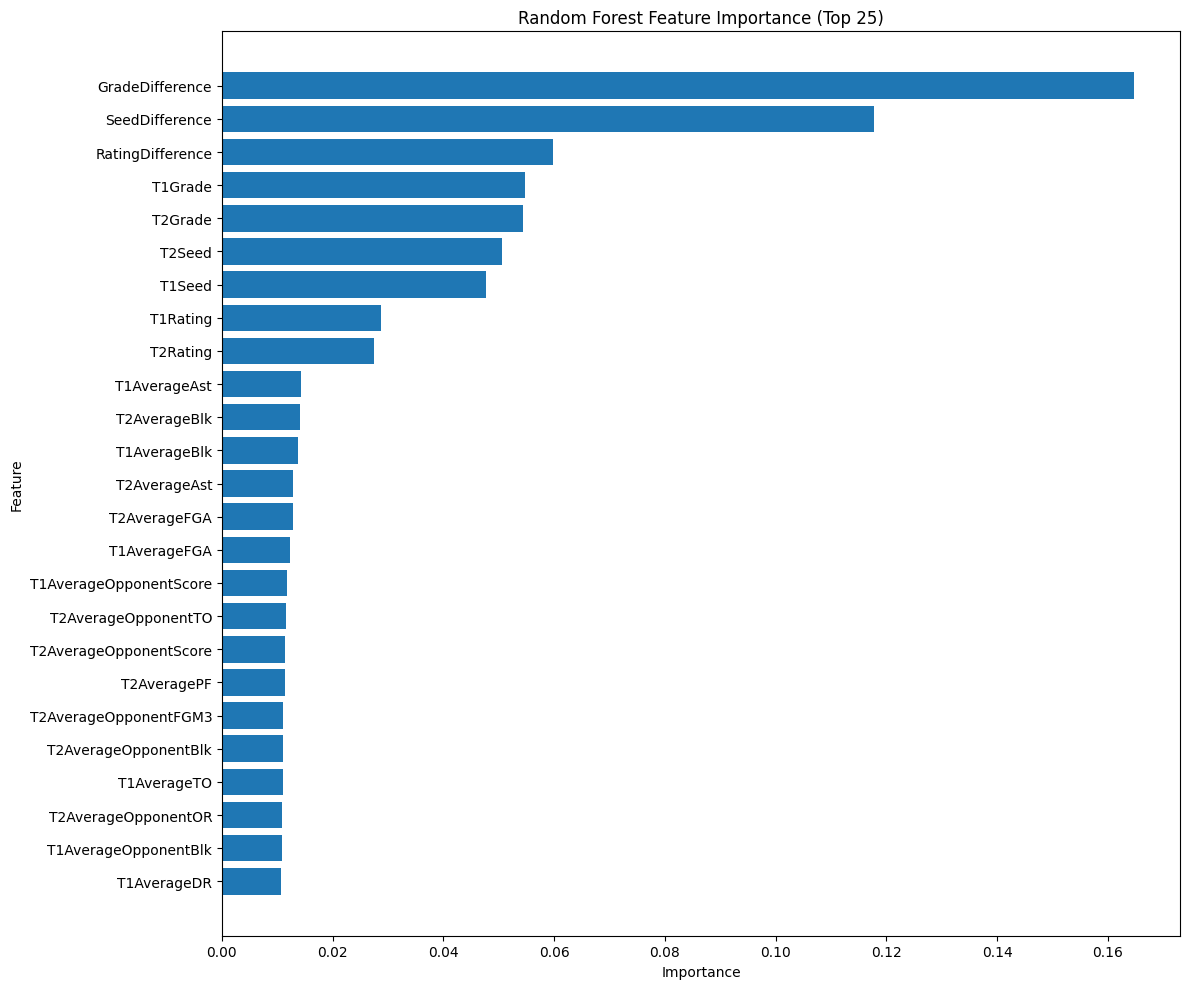

In [8]:
df_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_rf_model.feature_importances_
}).sort_values(by="Importance", ascending=True).tail(25)

plt.figure(figsize=(12, 10))
plt.barh(df_importance["Feature"], df_importance["Importance"])

plt.title("Random Forest Feature Importance (Top 25)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [9]:
# Train and test model using only the top 3 features

TOP3_FEATURES = df_importance["Feature"].tail(3).tolist()
print(f"\n Top 3 Features: {TOP3_FEATURES}")

X_top3 = df_train[TOP3_FEATURES]

results_top3 = []

oof_probs_top3 = np.zeros(len(y))
oof_preds_top3 = np.zeros(len(y))

for season in seasons_all:
  mask_train = df_train["Season"] != season
  mask_val = df_train["Season"] == season

  X_train_t3 = X_top3[mask_train]
  X_test_t3 = X_top3[mask_val]
  y_train_t3 = y[mask_train]
  y_test_t3 = y[mask_val]

  test_index = df_train.index[mask_val]

  rf_top3 = RandomForestClassifier(**best_params)
  rf_top3.fit(X_train_t3, y_train_t3)

  probs = rf_top3.predict_proba(X_test_t3)[:,1]
  preds = rf_top3.predict(X_test_t3)

  oof_probs_top3[test_index] = probs
  oof_preds_top3[test_index] = preds

  accuracy = accuracy_score(y_test_t3, preds)
  log_loss_score = log_loss(y_test_t3, probs)
  brier_score = brier_score_loss(y_test_t3, probs)

  results_top3.append({
      "Season": season,
      "Accuracy": accuracy,
      "Log Loss": log_loss_score,
      "Brier Score": brier_score
  })

  print(f"Season {season} | Accuracy: {accuracy:.4f} | Log Loss: {log_loss_score:.4f} | Brier Score: {brier_score:.4f}")

df_results_top3 = pd.DataFrame(results_top3).sort_values("Season")

print("\nAverage Performance Metrics for Top 3 Features")
print(f"Accuracy: {df_results_top3['Accuracy'].mean():.4f}")
print(f"Log Loss: {df_results_top3['Log Loss'].mean():.4f}")
print(f"Brier Score: {df_results_top3['Brier Score'].mean():.4f}")

# Train final model on all data
final_rf_model_top3 = RandomForestClassifier(**best_params)
final_rf_model_top3.fit(X_top3, y)



 Top 3 Features: ['RatingDifference', 'SeedDifference', 'GradeDifference']
Season 2003 | Accuracy: 0.7031 | Log Loss: 0.5308 | Brier Score: 0.1855
Season 2004 | Accuracy: 0.7031 | Log Loss: 0.5027 | Brier Score: 0.1722
Season 2005 | Accuracy: 0.7500 | Log Loss: 0.5341 | Brier Score: 0.1757
Season 2006 | Accuracy: 0.6875 | Log Loss: 0.5791 | Brier Score: 0.1987
Season 2007 | Accuracy: 0.7578 | Log Loss: 0.4544 | Brier Score: 0.1504
Season 2008 | Accuracy: 0.7500 | Log Loss: 0.4767 | Brier Score: 0.1604
Season 2009 | Accuracy: 0.7422 | Log Loss: 0.4882 | Brier Score: 0.1633
Season 2010 | Accuracy: 0.7047 | Log Loss: 0.5311 | Brier Score: 0.1835
Season 2011 | Accuracy: 0.7038 | Log Loss: 0.5113 | Brier Score: 0.1757
Season 2012 | Accuracy: 0.7692 | Log Loss: 0.4876 | Brier Score: 0.1606
Season 2013 | Accuracy: 0.7077 | Log Loss: 0.5405 | Brier Score: 0.1816
Season 2014 | Accuracy: 0.7115 | Log Loss: 0.5134 | Brier Score: 0.1767
Season 2015 | Accuracy: 0.8077 | Log Loss: 0.4493 | Brier Sc

RandomForestClassifier(criterion='entropy', max_depth=10, min_samples_leaf=8,
                       n_estimators=300, n_jobs=-1, random_state=1)

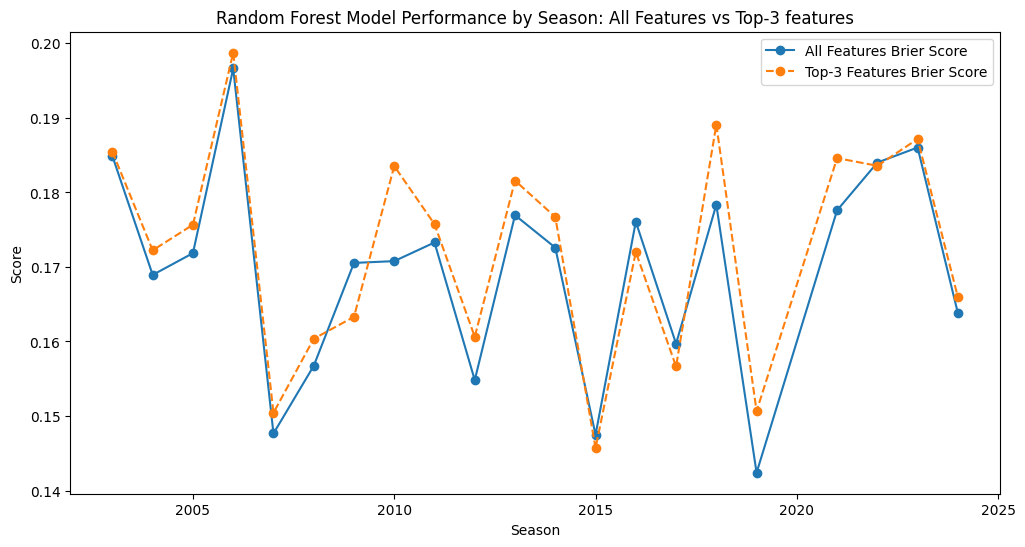

In [10]:
# Plot brier score graph

plt.figure(figsize=(12, 6))
plt.plot(df_results["Season"], df_results["Brier Score"], marker='o', label='All Features Brier Score')
plt.plot(df_results_top3["Season"], df_results_top3["Brier Score"], marker='o', linestyle='--', label='Top-3 Features Brier Score')

plt.title("Random Forest Model Performance by Season: All Features vs Top-3 features")
plt.xlabel("Season")
plt.ylabel("Score")
plt.legend()
plt.show()

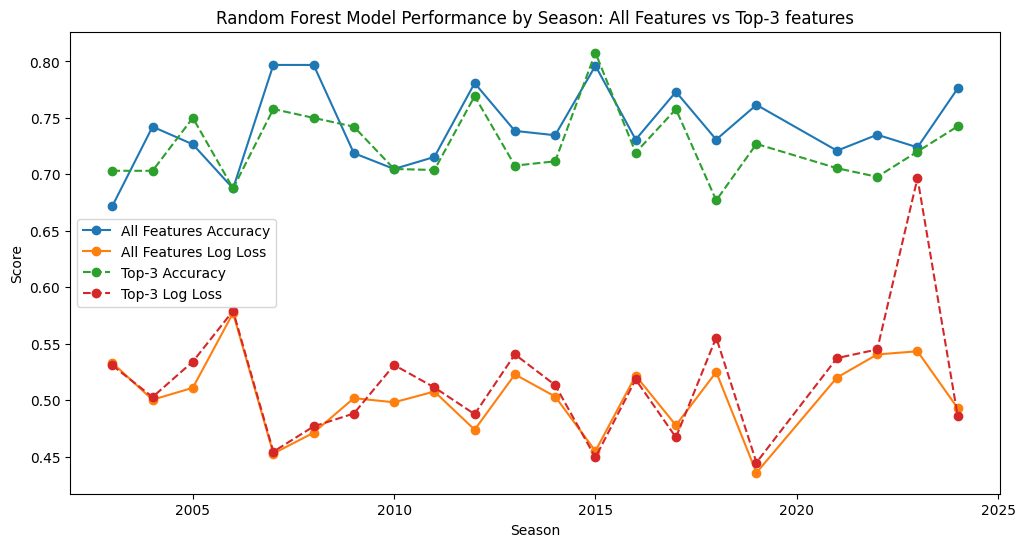

In [11]:
# Plot accuracy and log loss graph

plt.figure(figsize=(12, 6))
plt.plot(df_results["Season"], df_results["Accuracy"], marker='o', label='All Features Accuracy')
plt.plot(df_results["Season"], df_results["Log Loss"], marker='o', label='All Features Log Loss')
plt.plot(df_results_top3["Season"], df_results_top3["Accuracy"], marker='o', linestyle='--', label='Top-3 Accuracy')
plt.plot(df_results_top3["Season"], df_results_top3["Log Loss"], marker='o', linestyle='--', label='Top-3 Log Loss')


plt.title("Random Forest Model Performance by Season: All Features vs Top-3 features")
plt.xlabel("Season")
plt.ylabel("Score")
plt.legend()
plt.show()

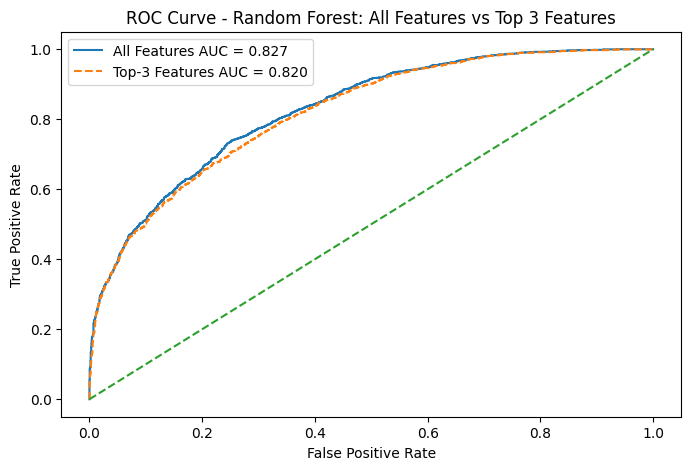

In [12]:
fpr, tpr, _ = roc_curve(y, oof_probs)
roc_auc = auc(fpr, tpr)

fpr3, tpr3, _ = roc_curve(y, oof_probs_top3)
roc_auc3 = auc(fpr3, tpr3)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"All Features AUC = {roc_auc:.3f}")
plt.plot(fpr3, tpr3, label=f"Top-3 Features AUC = {roc_auc3:.3f}", linestyle='--')
plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Random Forest: All Features vs Top 3 Features")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

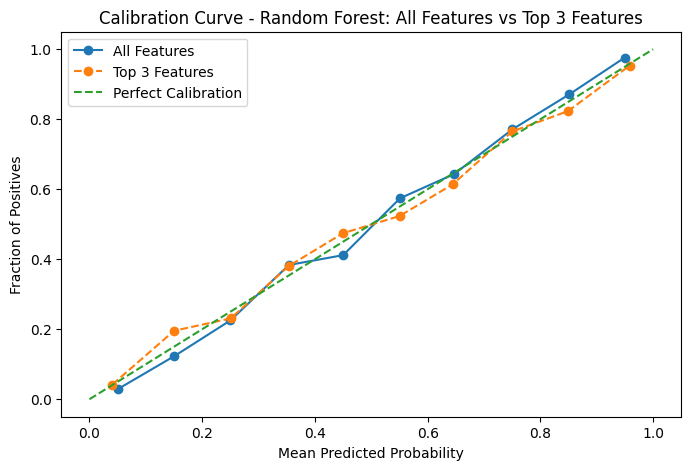

In [13]:
fraction_of_positives, mean_predicted_value = calibration_curve(y, oof_probs, n_bins=10)
fraction_of_positives_top3, mean_predicted_value_top3 = calibration_curve(y, oof_probs_top3, n_bins=10)

plt.figure(figsize=(8, 5))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label='All Features')
plt.plot(mean_predicted_value_top3, fraction_of_positives_top3, marker='o', label='Top 3 Features', linestyle='--')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect Calibration')

plt.title("Calibration Curve - Random Forest: All Features vs Top 3 Features")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.legend()
plt.show()

In [14]:
# Generate submission predictions for all features

missing_pred_cols = [f for f in FEATURES if f not in df_pred.columns]
if missing_pred_cols:
    print(f"Warning: features missing from prediction file: {missing_pred_cols}")
    for col in missing_pred_cols:
        df_pred[col] = 0

X_pred = df_pred[FEATURES]
ensemble_probs = np.clip(final_rf_model.predict_proba(X_pred)[:, 1], 0.01, 0.99)

print(f"Prediction range: [{ensemble_probs.min():.4f}, {ensemble_probs.max():.4f}]")
print(f"Mean predicted probability: {ensemble_probs.mean():.4f}  (should be ~0.50)")

Prediction range: [0.0100, 0.9900]
Mean predicted probability: 0.5116  (should be ~0.50)


In [15]:
# Generate submission predictions for top 3 features

missing_pred_cols_top3 = [f for f in TOP3_FEATURES if f not in df_pred.columns]
if missing_pred_cols_top3:
    print(f"Warning: top-3 features missing from prediction file: {missing_pred_cols_top3}")
    for col in missing_pred_cols_top3:
        df_pred[col] = 0

X_pred_top3 = df_pred[TOP3_FEATURES]
ensemble_probs_top3 = np.clip(final_rf_model_top3.predict_proba(X_pred_top3)[:, 1], 0.01, 0.99)

print(f"Top-3 Model Prediction range: [{ensemble_probs_top3.min():.4f}, {ensemble_probs_top3.max():.4f}]")
print(f"Top-3 Model Mean predicted probability: {ensemble_probs_top3.mean():.4f}  (should be ~0.50)")

Top-3 Model Prediction range: [0.0100, 0.9900]
Top-3 Model Mean predicted probability: 0.5060  (should be ~0.50)


In [16]:
#  Build submission dataframe

if "ID" in df_pred.columns:
    submission = df_pred[["ID"]].copy()
    submission_top3 = df_pred[["ID"]].copy()
else:
    # Build ID from Season + TeamID columns
    id_col = (
        df_pred["Season"].astype(str) + "_" +
        df_pred["T1TeamID"].astype(str) + "_" +
        df_pred["T2TeamID"].astype(str)
    )

    submission = pd.DataFrame({"ID": id_col})
    submission_top3 = pd.DataFrame({"ID": id_col})

submission["Pred"] = ensemble_probs
submission_top3["Pred"] = ensemble_probs_top3

print("All Features:")
print(submission.head(10))

print("Top-3 Features:")
print(submission_top3.head(10))

All Features:
               ID      Pred
0  2025_1101_1102  0.532743
1  2025_1101_1103  0.357954
2  2025_1101_1104  0.170239
3  2025_1101_1105  0.529951
4  2025_1101_1106  0.392848
5  2025_1101_1107  0.482755
6  2025_1101_1108  0.516399
7  2025_1101_1110  0.488107
8  2025_1101_1111  0.487974
9  2025_1101_1112  0.183573
Top-3 Features:
               ID      Pred
0  2025_1101_1102  0.602227
1  2025_1101_1103  0.307046
2  2025_1101_1104  0.105422
3  2025_1101_1105  0.592141
4  2025_1101_1106  0.491380
5  2025_1101_1107  0.489302
6  2025_1101_1108  0.621531
7  2025_1101_1110  0.560902
8  2025_1101_1111  0.506977
9  2025_1101_1112  0.118860


In [17]:
# Save submission

SUBMISSION_FILE = "submission_randomforest.csv"
submission[["ID", "Pred"]].to_csv(SUBMISSION_FILE, index=False)
print(f"Saved {len(submission):,} rows to '{SUBMISSION_FILE}'")

SUBMISSION_FILE_TOP3 = "submission_randomforest_top3.csv"
submission_top3[["ID", "Pred"]].to_csv(SUBMISSION_FILE_TOP3, index=False)
print(f"Saved {len(submission_top3):,} rows to '{SUBMISSION_FILE_TOP3}'")

try:
    files.download(SUBMISSION_FILE)
    files.download(SUBMISSION_FILE_TOP3)
except ImportError:
    print("Not running in Colab, file saved locally.")

Saved 131,407 rows to 'submission_randomforest.csv'
Saved 131,407 rows to 'submission_randomforest_top3.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>